In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

In [4]:
df = pd.read_csv('fcc-forum-pageviews.csv', index_col=0, parse_dates=True)
df.head()

,value
date,
2016-05-09,1201
2016-05-10,2329
2016-05-11,1716
2016-05-12,10539
2016-05-13,6933


In [8]:
df.shape

(1304, 1)

In [7]:
type(df.index[0])

pandas._libs.tslibs.timestamps.Timestamp

In [9]:
df.loc[
    (df['value'] >= df['value'].quantile(0.025)) &
    (df['value'] <= df['value'].quantile(0.975)), :
]

,value
date,
2016-05-19,19736
2016-05-26,18060
2016-05-27,19997
2016-05-28,19044
2016-05-29,20325
...,...
2019-11-24,138875
2019-11-29,171584
2019-11-30,141161


In [5]:
df = df.loc[
    (df['value'] >= df['value'].quantile(0.025)) &
    (df['value'] <= df['value'].quantile(0.975)), :
]

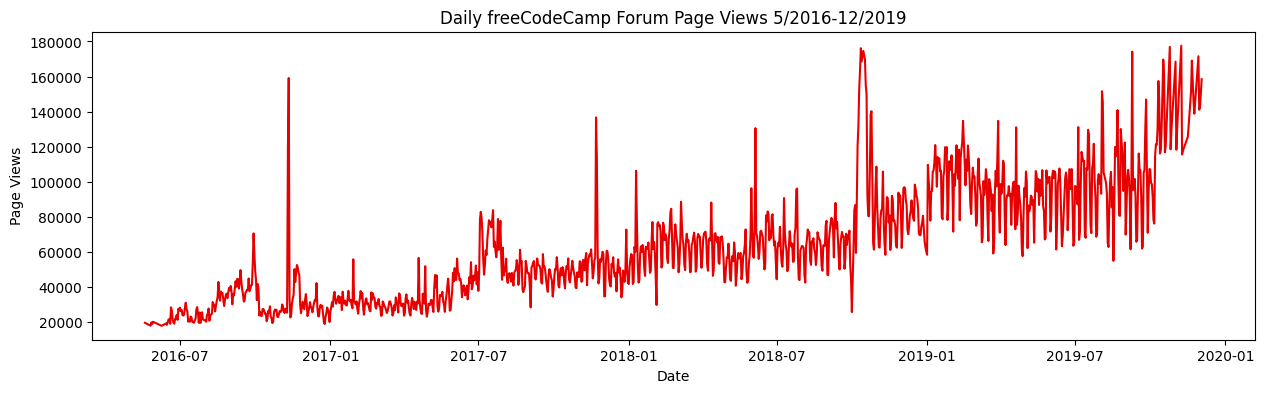

In [24]:
def draw_line_plot():
    fig, ax = plt.subplots()

    ax.plot(df, color="#E80000")

    ax.set_title('Daily freeCodeCamp Forum Page Views 5/2016-12/2019')
    ax.set_xlabel('Date')
    ax.set_ylabel('Page Views')

    fig.set_size_inches(15, 4)

    return fig


my_plot = draw_line_plot()

---

In [6]:
df_bar = df.copy()
df_bar = df_bar.reset_index()

In [7]:
df_bar.dtypes

date     datetime64[ns]
value             int64
dtype: object

In [87]:
df_bar['date'].iloc[0].month_name()

'May'

In [8]:
df_bar['month'] = df_bar['date'].dt.month_name()
df_bar.head()

,date,value,month
0,2016-05-19,19736,May
1,2016-05-26,18060,May
2,2016-05-27,19997,May
3,2016-05-28,19044,May
4,2016-05-29,20325,May


In [9]:
df_bar['year'] = df_bar['date'].dt.year
df_bar.head()

,date,value,month,year
0,2016-05-19,19736,May,2016
1,2016-05-26,18060,May,2016
2,2016-05-27,19997,May,2016
3,2016-05-28,19044,May,2016
4,2016-05-29,20325,May,2016


In [10]:
df_bar

,date,value,month,year
0,2016-05-19,19736,May,2016
1,2016-05-26,18060,May,2016
2,2016-05-27,19997,May,2016
3,2016-05-28,19044,May,2016
4,2016-05-29,20325,May,2016
...,...,...,...,...
1233,2019-11-24,138875,November,2019
1234,2019-11-29,171584,November,2019
1235,2019-11-30,141161,November,2019
1236,2019-12-01,142918,December,2019


In [ ]:
df_bar.groupby(['year', 'month'])['value'].mean()

year  month    
2016  August        31049.193548
      December      27832.419355
      July          24109.678571
      June          21875.105263
      May           19432.400000
      November      40448.633333
      October       27398.322581
      September     41476.866667
2017  April         30878.733333
      August        47712.451613
      December      48420.580645
      February      31113.071429
      January       32785.161290
      July          65806.838710
      June          43577.500000
      March         29369.096774
      May           34244.290323
      November      57701.566667
      October       47438.709677
      September     47376.800000
2018  April         62350.833333
      August        62831.612903
      December      80047.483871
      February      65679.000000
      January       58580.096774
      July          63591.064516
      June          70117.000000
      March         62693.774194
      May           56562.870968
      November      78688.3

In [ ]:
# we get multiindex because we grouped by several columns
df_bar.groupby(['year', 'month'])['value'].mean().index

MultiIndex([(2016,    'August'),
            (2016,  'December'),
            (2016,      'July'),
            (2016,      'June'),
            (2016,       'May'),
            (2016,  'November'),
            (2016,   'October'),
            (2016, 'September'),
            (2017,     'April'),
            (2017,    'August'),
            (2017,  'December'),
            (2017,  'February'),
            (2017,   'January'),
            (2017,      'July'),
            (2017,      'June'),
            (2017,     'March'),
            (2017,       'May'),
            (2017,  'November'),
            (2017,   'October'),
            (2017, 'September'),
            (2018,     'April'),
            (2018,    'August'),
            (2018,  'December'),
            (2018,  'February'),
            (2018,   'January'),
            (2018,      'July'),
            (2018,      'June'),
            (2018,     'March'),
            (2018,       'May'),
            (2018,  'November'),
          

In [ ]:
df_bar.groupby('year')['value'].mean().index

Index([2016, 2017, 2018, 2019], dtype='int32', name='year')

In [11]:
df_bar = df.copy()
df_bar = df_bar.reset_index()

df_bar['month'] = df_bar['date'].dt.month_name()
df_bar['year'] = df_bar['date'].dt.year
df_bar.set_index('date', inplace=True)

df_bar = df_bar.groupby(['year', 'month'])['value'].mean()
df_bar.head()

year  month   
2016  August      31049.193548
      December    27832.419355
      July        24109.678571
      June        21875.105263
      May         19432.400000
Name: value, dtype: float64

In [116]:
df_bar.info()

<class 'pandas.core.series.Series'>
MultiIndex: 44 entries, (np.int32(2016), 'August') to (np.int32(2019), 'September')
Series name: value
Non-Null Count  Dtype  
--------------  -----  
44 non-null     float64
dtypes: float64(1)
memory usage: 799.0+ bytes


In [2]:
df_bar.index

NameError: name 'df_bar' is not defined

In [12]:
month_mapping = {}

for n in range(12):
    month_name = pd.to_datetime(f'{n+1}/1/1').month_name()
    month_mapping[month_name] = n

month_mapping

{'January': 0,
 'February': 1,
 'March': 2,
 'April': 3,
 'May': 4,
 'June': 5,
 'July': 6,
 'August': 7,
 'September': 8,
 'October': 9,
 'November': 10,
 'December': 11}

In [13]:
df_bar = df_bar.unstack().sort_index(axis=1, key=lambda x: x.map(month_mapping))
df_bar

month,January,February,March,April,May,June,July,August,September,October,November,December
year,,,,,,,,,,,,
2016,NaN,NaN,NaN,NaN,19432.400000,21875.105263,24109.678571,31049.193548,41476.866667,27398.322581,40448.633333,27832.419355
2017,32785.161290,31113.071429,29369.096774,30878.733333,34244.290323,43577.500000,65806.838710,47712.451613,47376.800000,47438.709677,57701.566667,48420.580645
2018,58580.096774,65679.000000,62693.774194,62350.833333,56562.870968,70117.000000,63591.064516,62831.612903,65941.733333,111378.142857,78688.333333,80047.483871
2019,102056.516129,105968.357143,91214.483871,89368.433333,91439.903226,90435.642857,97236.566667,102717.310345,97268.833333,122802.272727,143166.428571,150733.500000


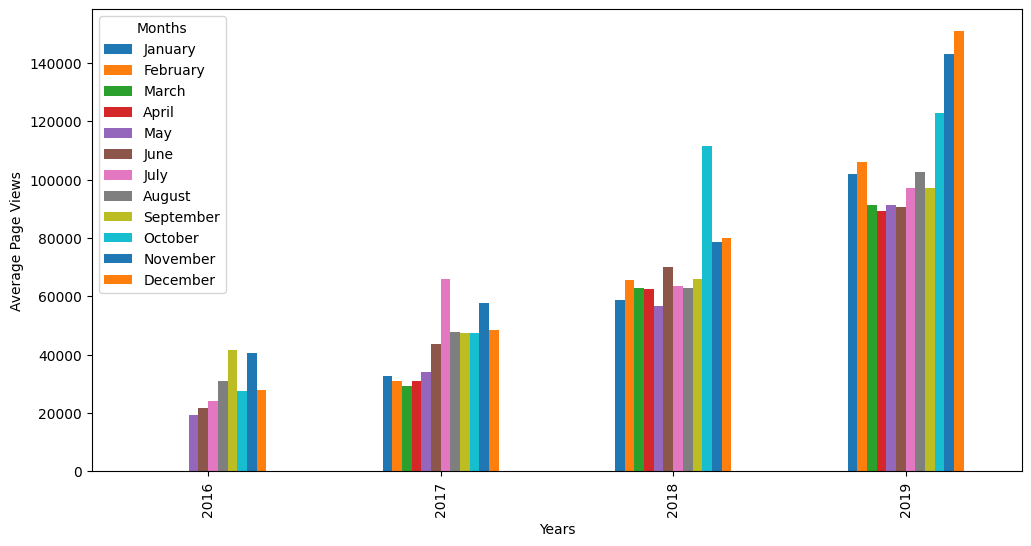

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))

df_bar.plot.bar(ax=ax)
ax.set_xlabel('Years')
ax.set_ylabel('Average Page Views')
ax.legend(title='Months')

---

In [175]:
df_box = df.copy()
df_box.reset_index(inplace=True)
df_box['year'] = df_box['date'].dt.year
df_box['month'] = df_box['date'].dt.month_name()
df_box.sort_values('month', key=lambda x: x.map(month_mapping), inplace=True)
df_box

,date,value,year,month
955,2019-01-24,114541,2019,January
950,2019-01-19,79858,2019,January
952,2019-01-21,103240,2019,January
951,2019-01-20,78679,2019,January
956,2019-01-25,119836,2019,January
...,...,...,...,...
921,2018-12-21,85083,2018,December
569,2017-12-31,42616,2017,December
568,2017-12-30,50169,2017,December
567,2017-12-29,72819,2017,December


In [176]:
df_box['month'] = df_box['month'].str[:3]

In [177]:
df_box

,date,value,year,month
955,2019-01-24,114541,2019,Jan
950,2019-01-19,79858,2019,Jan
952,2019-01-21,103240,2019,Jan
951,2019-01-20,78679,2019,Jan
956,2019-01-25,119836,2019,Jan
...,...,...,...,...
921,2018-12-21,85083,2018,Dec
569,2017-12-31,42616,2017,Dec
568,2017-12-30,50169,2017,Dec
567,2017-12-29,72819,2017,Dec


Text(0, 0.5, 'Page Views')

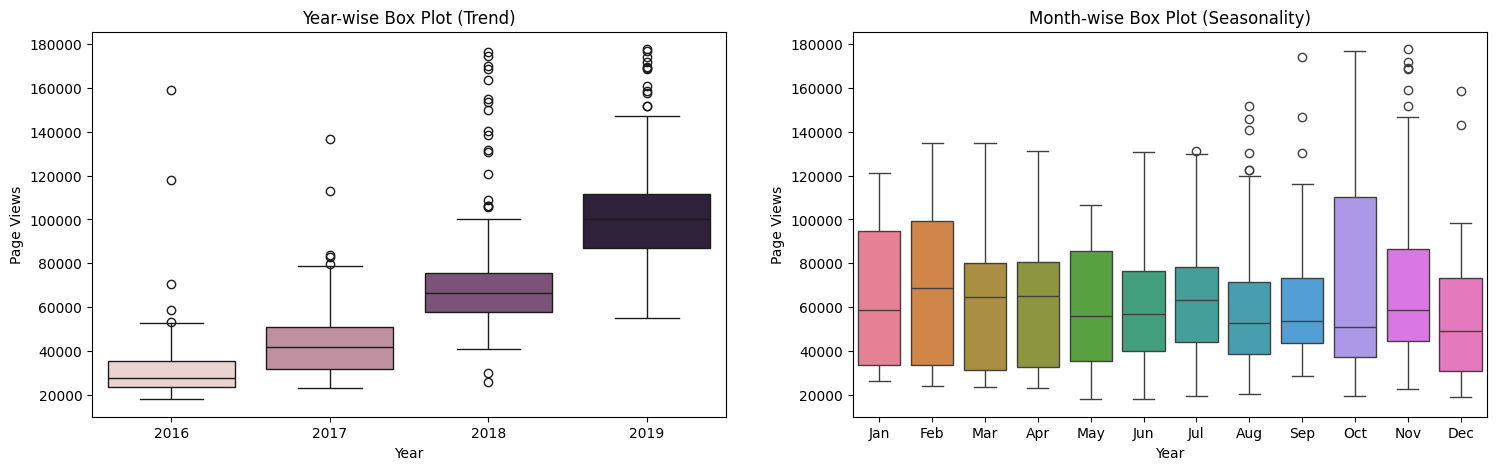

In [178]:
fig, axes = plt.subplots(1, 2)
fig.set_size_inches(18, 5)

# noted that seaborn would show the legend only on the first ax without the flag
ax1 = sns.boxplot(df_box, x='year', y='value', ax=axes[0], hue='year', legend=False)
ax1.set_title('Year-wise Box Plot (Trend)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Page Views')

ax2 = sns.boxplot(df_box, x='month', y='value', ax=axes[1], hue='month', legend=False)
ax2.set_title('Month-wise Box Plot (Seasonality)')
ax2.set_xlabel('Year')
ax2.set_ylabel('Page Views')